In [7]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [15]:
train_dir = "train"
test_dir = "test"

## Load the training data

In [16]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 895 files belonging to 2 classes.


## Load test data

In [17]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 376 files belonging to 2 classes.


## Performance Optimization

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

In [23]:
import os

class_names = sorted(os.listdir(train_dir))
print(class_names)

['Benign', 'Malignant']


## Sample Image

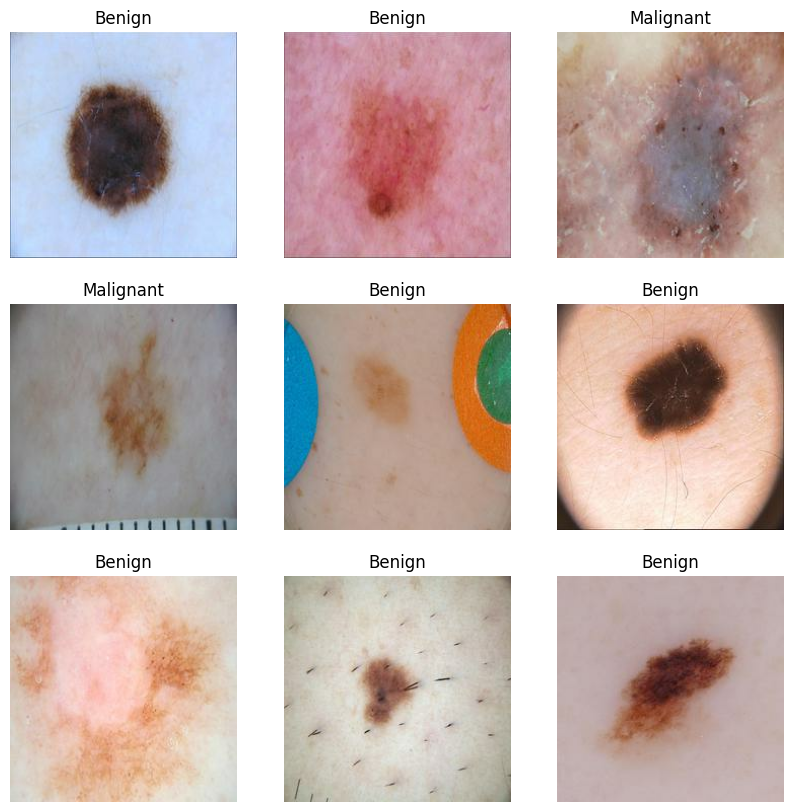

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

## The actual CNN model

In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [26]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.7587 - loss: 0.5564 - val_accuracy: 0.8032 - val_loss: 0.4752
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step - accuracy: 0.8089 - loss: 0.4549 - val_accuracy: 0.8085 - val_loss: 0.4649
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.8134 - loss: 0.4388 - val_accuracy: 0.8032 - val_loss: 0.4490
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.8156 - loss: 0.4171 - val_accuracy: 0.8112 - val_loss: 0.4373
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 251ms/step - accuracy: 0.8223 - loss: 0.4119 - val_accuracy: 0.8085 - val_loss: 0.4360
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.8324 - loss: 0.3970 - val_accuracy: 0.8032 - val_loss: 0.4376
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - accuracy: 0.8212 - loss: 0.3953 - val_accuracy: 0.8059 - val_loss: 0.4383
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.8391 - loss: 0.3783 - val_accuracy: 0

In [29]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8112 - loss: 0.4463
Test Accuracy: 0.811170220375061


In [32]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/Desktop/skin disease detection /Preprocessed_Data/test/Benign/", target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

print("Prediction:", prediction)

FileNotFoundError: [Errno 2] No such file or directory: '/Desktop/skin disease detection /Preprocessed_Data/test/Benign/'

In [33]:
import os
import random

folder = "/Users/sadhana/Desktop/skin disease detection/Preprocessed_Data/test/Benign"

img_file = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_file)

print("Using image:", img_file)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sadhana/Desktop/skin disease detection/Preprocessed_Data/test/Benign'

In [34]:
import os
print(os.path.expanduser("~"))

/Users/sadhanauprety


In [35]:
import os

for item in os.listdir("/Users/sadhanauprety/Desktop"):
    print(item)

Machine Learning
skin disease detection
download.png
.DS_Store
skin disease detection 
.localized
sem project
adk_project
broker.pdf
Gmail - ALL FD RECEIPT.pdf
DL
For Lab 3,4.pdf
.ipynb_checkpoints
sk-learn
Fast_api
Scientific Computing


In [36]:
import os

base = "/Users/sadhanauprety/Desktop"

for item in os.listdir(base):
    if "skin" in item.lower():
        print("FOUND:", item)

FOUND: skin disease detection
FOUND: skin disease detection 


In [37]:
import os

folder = os.path.join(
    "/Users/sadhanauprety/Desktop",
    "skin disease detection ", 
    "Preprocessed_Data",
    "test",
    "Benign"
)

In [38]:
import random
from tensorflow.keras.preprocessing import image
import os

img_file = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_file)

img = image.load_img(img_path, target_size=(224, 224))

In [42]:
import os
import random
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# STEP 1: pick a random image from folder
img_file = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_file)

print("Using image:", img_file)

# STEP 2: load image
img = image.load_img(img_path, target_size=(224, 224))

# STEP 3: convert to array
img_array = image.img_to_array(img)

# STEP 4: add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# STEP 5: preprocess (IMPORTANT for MobileNetV2)
img_array = preprocess_input(img_array)

# STEP 6: predict
prediction = model.predict(img_array)

# STEP 7: interpret result (binary classification)
confidence = prediction[0][0]

if confidence > 0.5:
    print(f"Prediction: Malignant ({confidence*100:.2f}%)")
else:
    print(f"Prediction: Benign  ({(1-confidence)*100:.2f}%)")

Using image: ISIC_0000527.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: Benign  (100.00%)


In [43]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 0.8112 - loss: 0.4463
Test Accuracy: 0.811170220375061


In [44]:
preds = model.predict(test_data)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step
